# Phase 1 — Exploratory Data Analysis

MSIT Time Series Forecasting Project  
**Dataset:** Corporación Favorita (Ecuador grocery chain) — aggregated daily unit sales  
**Date range:** 2013-01-02 → 2014-03-31  

This notebook profiles all four data files, checks quality, and produces the charts needed to motivate modelling decisions in Phases 2–3.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
BLUE   = '#2563EB'
ORANGE = '#F59E0B'
GREEN  = '#10B981'
RED    = '#EF4444'

print('Imports OK')
print(f'pandas {pd.__version__}  |  numpy {np.__version__}  |  matplotlib {matplotlib.__version__}')

Imports OK
pandas 2.3.3  |  numpy 2.4.4  |  matplotlib 3.10.9


---
## 1. Load Data

In [2]:
ROOT = '..'

ts       = pd.read_csv(f'{ROOT}/data/timeseries.csv', parse_dates=['date'])
oil      = pd.read_csv(f'{ROOT}/data/oil.csv',        parse_dates=['date'])
stores   = pd.read_csv(f'{ROOT}/data/stores.csv')
holidays = pd.read_csv(f'{ROOT}/data/holidays.csv',   parse_dates=['date'])

ts = ts.sort_values('date').reset_index(drop=True)

print('timeseries : ', ts.shape)
print('oil        : ', oil.shape)
print('stores     : ', stores.shape)
print('holidays   : ', holidays.shape)

timeseries :  (452, 2)
oil        :  (1218, 2)
stores     :  (54, 3)
holidays   :  (350, 4)


---
## 2. Dataset Summaries

In [3]:
# ── timeseries ───────────────────────────────────────────────────
print('=== timeseries.csv ===')
print(ts.dtypes)
print()
print(ts.describe())
print()
print(f'Date range  : {ts.date.min().date()} → {ts.date.max().date()}')
print(f'Calendar days: {(ts.date.max()-ts.date.min()).days+1}')
print(f'Actual rows  : {len(ts)}')

# Missing days = store-closed public holidays
full_range = pd.date_range(ts.date.min(), ts.date.max())
missing = full_range.difference(ts.date)
print(f'Missing days : {len(missing)}  → {list(missing.date)}')
print(f'Null values  : {ts.isnull().sum().to_dict()}')
print(f'Zero sales   : {(ts.unit_sales==0).sum()}')
print(f'Negative sales: {(ts.unit_sales<0).sum()}')

=== timeseries.csv ===
date          datetime64[ns]
unit_sales           float64
dtype: object

                                date   unit_sales
count                            452   452.000000
mean   2013-08-15 21:46:11.681415936   480.090708
min              2013-01-02 00:00:00     4.000000
25%              2013-04-24 18:00:00   358.000000
50%              2013-08-15 12:00:00   445.500000
75%              2013-12-06 06:00:00   578.250000
max              2014-03-31 00:00:00  1203.000000
std                              NaN   170.839776

Date range  : 2013-01-02 → 2014-03-31
Calendar days: 454
Actual rows  : 452
Missing days : 2  → [datetime.date(2013, 12, 25), datetime.date(2014, 1, 1)]
Null values  : {'date': 0, 'unit_sales': 0}
Zero sales   : 0
Negative sales: 0


In [4]:
# ── oil ──────────────────────────────────────────────────────────
print('=== oil.csv ===')
print(oil.describe())
print(f'Date range  : {oil.date.min().date()} → {oil.date.max().date()}')
print(f'Null prices : {oil.dcoilwtico.isna().sum()} ({oil.dcoilwtico.isna().mean()*100:.1f}%)')

=== oil.csv ===
                      date   dcoilwtico
count                 1218  1175.000000
mean   2015-05-02 12:00:00    67.714366
min    2013-01-01 00:00:00    26.190000
25%    2014-03-03 06:00:00    46.405000
50%    2015-05-02 12:00:00    53.190000
75%    2016-06-30 18:00:00    95.660000
max    2017-08-31 00:00:00   110.620000
std                    NaN    25.630476
Date range  : 2013-01-01 → 2017-08-31
Null prices : 43 (3.5%)


In [5]:
# ── stores ───────────────────────────────────────────────────────
print('=== stores.csv ===')
print(f'Stores: {len(stores)}  |  Cities: {stores.city.nunique()}  |  Regions: {stores.region.nunique()}')
print()
print(stores.groupby('region')['store_nbr'].count().sort_values(ascending=False).rename('store_count'))

=== stores.csv ===
Stores: 54  |  Cities: 22  |  Regions: 16

region
Pichincha                         19
Guayas                            11
Azuay                              3
Manabi                             3
Santo Domingo de los Tsachilas     3
Cotopaxi                           2
El Oro                             2
Los Rios                           2
Tungurahua                         2
Bolivar                            1
Chimborazo                         1
Esmeraldas                         1
Imbabura                           1
Loja                               1
Pastaza                            1
Santa Elena                        1
Name: store_count, dtype: int64


In [6]:
# ── holidays ─────────────────────────────────────────────────────
print('=== holidays.csv ===')
print(holidays.locale.value_counts())
print()
national = holidays[holidays.locale == 'National'].copy()
natl_in_range = national[(national.date >= ts.date.min()) & (national.date <= ts.date.max())]
print(f'National holidays in TS range: {len(natl_in_range)}')
print(natl_in_range[['date','description']].sort_values('date').to_string(index=False))

=== holidays.csv ===
locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

National holidays in TS range: 24
      date                         description
2013-01-05             Recupero puente Navidad
2013-01-12  Recupero puente primer dia del ano
2013-02-11                            Carnaval
2013-02-12                            Carnaval
2013-04-29                       Viernes Santo
2013-05-01                     Dia del Trabajo
2013-05-11                   Dia de la Madre-1
2013-05-12                     Dia de la Madre
2013-05-24                Batalla de Pichincha
2013-08-10       Primer Grito de Independencia
2013-10-09          Independencia de Guayaquil
2013-10-11 Traslado Independencia de Guayaquil
2013-11-02                     Dia de Difuntos
2013-11-03             Independencia de Cuenca
2013-12-21                           Navidad-4
2013-12-22                           Navidad-3
2013-12-23                           Navidad-2
2013-12-24       

---
## 3. Time Series Overview

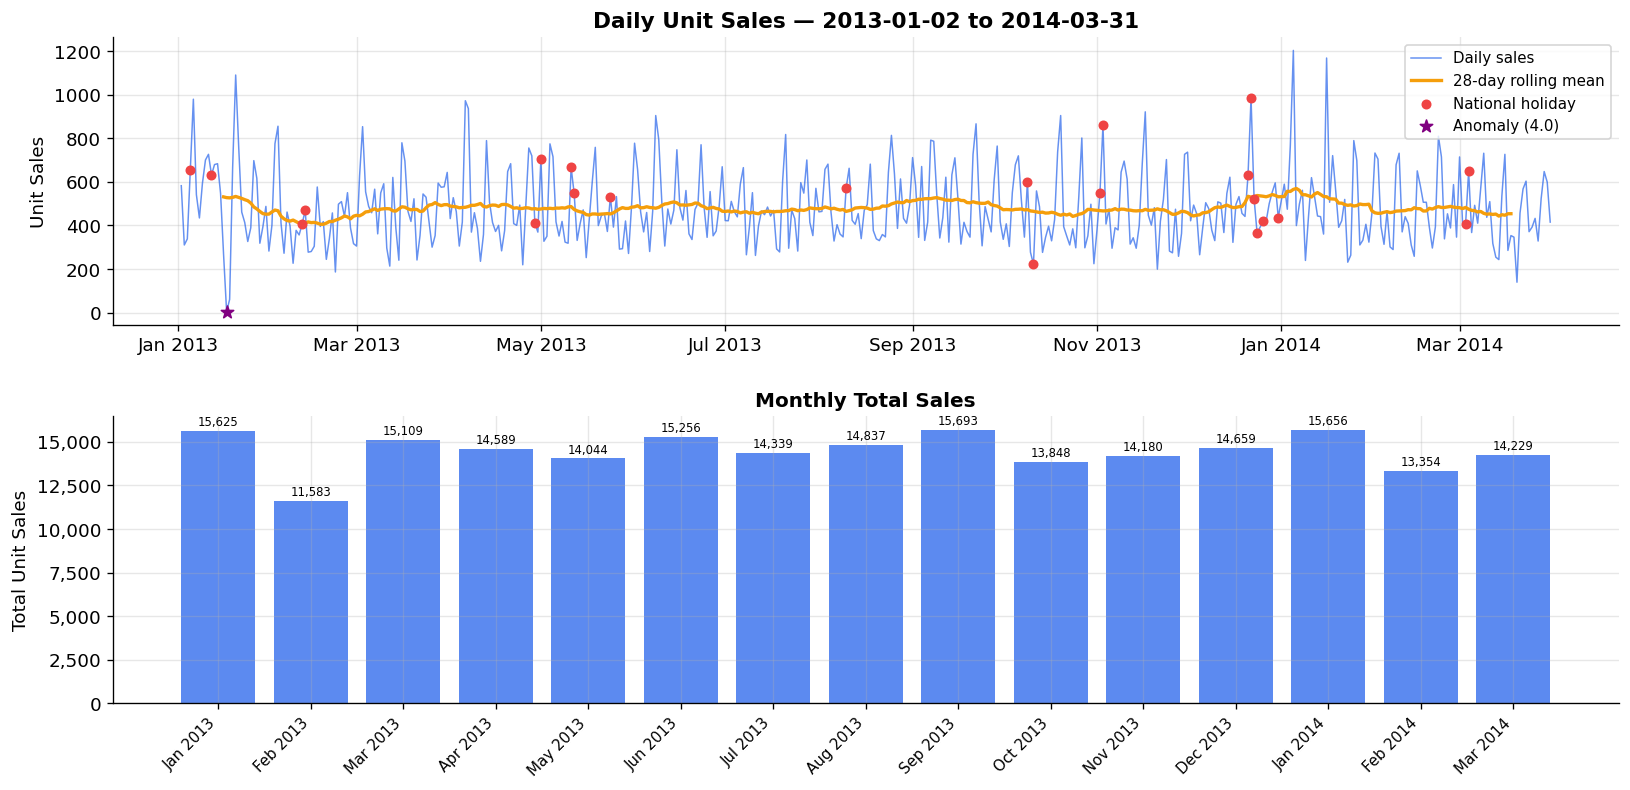

Saved: fig_01_timeseries_overview.png


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# ── Top: full daily series ────────────────────────────────────────
ax = axes[0]
ax.plot(ts.date, ts.unit_sales, color=BLUE, lw=0.9, alpha=0.7, label='Daily sales')
ax.plot(ts.date, ts.unit_sales.rolling(28, center=True).mean(),
        color=ORANGE, lw=2, label='28-day rolling mean')

# Mark national holidays
natl = natl_in_range.copy()
natl_sales = ts[ts.date.isin(natl.date)]
ax.scatter(natl_sales.date, natl_sales.unit_sales, color=RED, s=25, zorder=5, label='National holiday')

# Mark the suspicious low
low = ts[ts.unit_sales < 10]
ax.scatter(low.date, low.unit_sales, color='purple', s=60, marker='*', zorder=6, label='Anomaly (4.0)')

ax.set_title('Daily Unit Sales — 2013-01-02 to 2014-03-31', fontsize=13, fontweight='bold')
ax.set_ylabel('Unit Sales')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.legend(fontsize=9)

# ── Bottom: monthly totals bar chart ─────────────────────────────
ax2 = axes[1]
ts['month'] = ts.date.dt.to_period('M')
monthly = ts.groupby('month')['unit_sales'].sum().reset_index()
monthly['month_str'] = monthly['month'].dt.strftime('%b %Y')
bars = ax2.bar(range(len(monthly)), monthly.unit_sales, color=BLUE, alpha=0.75, width=0.8)
ax2.set_xticks(range(len(monthly)))
ax2.set_xticklabels(monthly.month_str, rotation=45, ha='right', fontsize=9)
ax2.set_title('Monthly Total Sales', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Unit Sales')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
# Annotate bars
for i, v in enumerate(monthly.unit_sales):
    ax2.text(i, v + 150, f'{v:,.0f}', ha='center', va='bottom', fontsize=7)

fig.tight_layout(pad=2)
plt.savefig(f'{ROOT}/images/fig_01_timeseries_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: fig_01_timeseries_overview.png')

**Observations:**
- No strong upward/downward trend — the series is roughly stationary in mean (~480 units/day).
- Clear **weekly seasonality**: peaks on weekends.
- National holidays often show **suppressed sales** (many marked in red below the rolling mean).
- One anomalous observation on **2013-01-17** with only 4 units — investigate before modelling.
- December holiday cluster (Navidad) shows elevated multi-day activity.

---
## 4. Weekly Seasonality

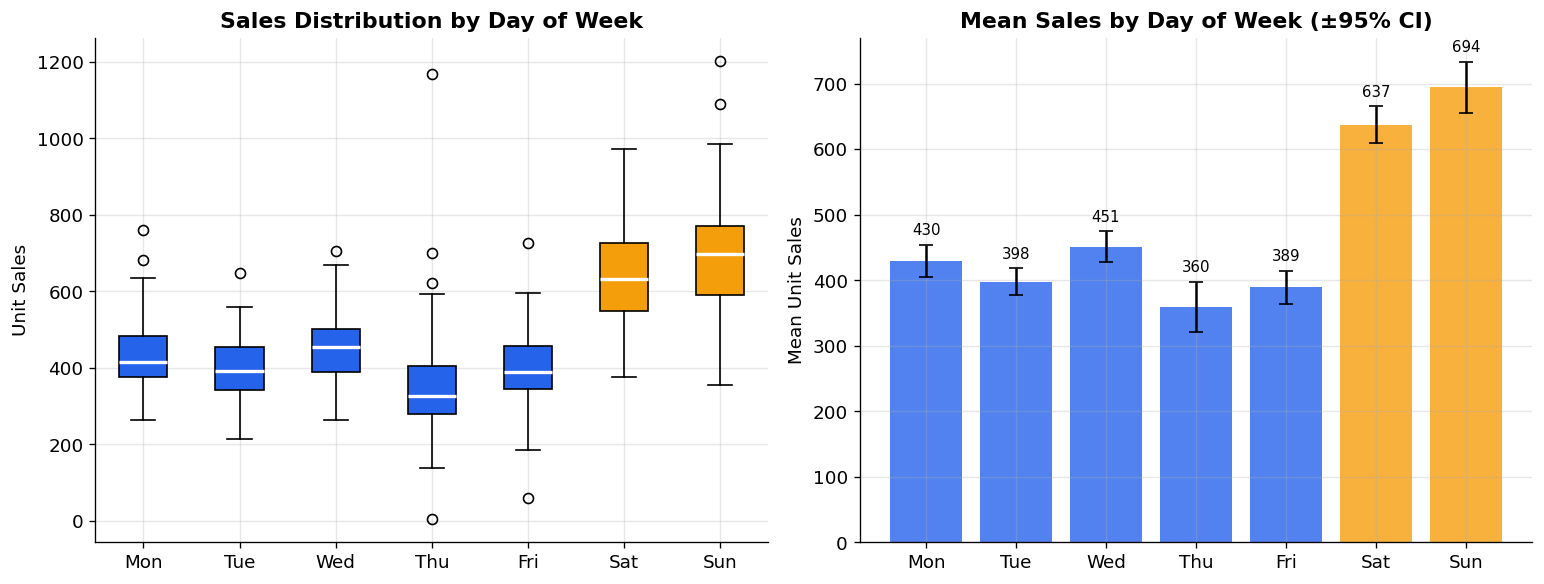

Saved: fig_02_weekly_seasonality.png


In [8]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ts['dow'] = pd.Categorical(ts.date.dt.day_name(), categories=dow_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: boxplot ────────────────────────────────────────────────
groups = [ts.loc[ts.dow == d, 'unit_sales'].values for d in dow_order]
bp = axes[0].boxplot(groups, patch_artist=True, medianprops=dict(color='white', lw=2))
colors = [BLUE]*5 + [ORANGE, ORANGE]
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
axes[0].set_xticklabels([d[:3] for d in dow_order])
axes[0].set_title('Sales Distribution by Day of Week', fontweight='bold')
axes[0].set_ylabel('Unit Sales')

# ── Right: mean + 95% CI ─────────────────────────────────────────
dow_stats = ts.groupby('dow', observed=True)['unit_sales'].agg(['mean','std','count']).reset_index()
dow_stats['se'] = dow_stats['std'] / np.sqrt(dow_stats['count'])
dow_stats['ci95'] = 1.96 * dow_stats['se']
colors2 = [BLUE]*5 + [ORANGE, ORANGE]
axes[1].bar(dow_stats.dow, dow_stats['mean'], color=colors2, alpha=0.8)
axes[1].errorbar(dow_stats.dow, dow_stats['mean'],
                 yerr=dow_stats['ci95'], fmt='none', color='black', capsize=4, lw=1.5)
axes[1].set_xticklabels([d[:3] for d in dow_order])
for i, row in dow_stats.iterrows():
    axes[1].text(i, row['mean'] + row['ci95'] + 10, f"{row['mean']:.0f}",
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('Mean Sales by Day of Week (±95% CI)', fontweight='bold')
axes[1].set_ylabel('Mean Unit Sales')

fig.tight_layout()
plt.savefig(f'{ROOT}/images/fig_02_weekly_seasonality.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: fig_02_weekly_seasonality.png')

**Observations:**
- **Saturday (+33%) and Sunday (+45%)** are dominant shopping days vs the weekday average.
- **Thursday** is the weakest weekday (~360 units mean).
- Weekly seasonality is highly consistent — models must capture a 7-day cycle.

---
## 5. Sales Distribution & Outlier Analysis

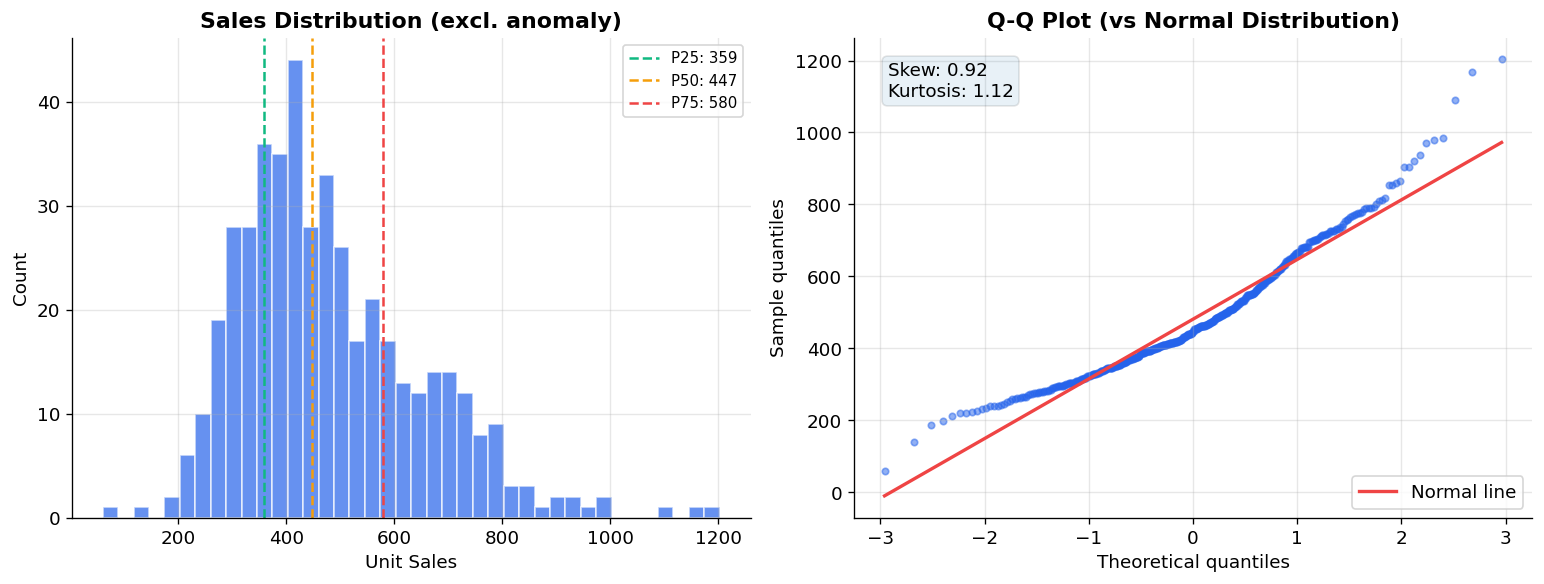

Skewness: 0.921  |  Kurtosis (excess): 1.117

Anomaly check — 2013-01-17: [[Timestamp('2013-01-17 00:00:00') 4.0]]


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: histogram + KDE ─────────────────────────────────────────
ax = axes[0]
# Exclude the anomaly for clean histogram
ts_clean = ts[ts.unit_sales >= 10]
ax.hist(ts_clean.unit_sales, bins=40, color=BLUE, alpha=0.7, edgecolor='white')
# Percentile lines
for pct, label, c in [(25,'P25',GREEN),(50,'P50',ORANGE),(75,'P75',RED)]:
    v = ts_clean.unit_sales.quantile(pct/100)
    ax.axvline(v, color=c, lw=1.5, linestyle='--', label=f'{label}: {v:.0f}')
ax.set_title('Sales Distribution (excl. anomaly)', fontweight='bold')
ax.set_xlabel('Unit Sales')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── Right: Q-Q vs normal ──────────────────────────────────────────
from scipy import stats as scipy_stats
ax2 = axes[1]
(osm, osr), (slope, intercept, _) = scipy_stats.probplot(ts_clean.unit_sales, dist='norm')
ax2.scatter(osm, osr, alpha=0.5, s=15, color=BLUE)
ax2.plot(osm, slope * np.array(osm) + intercept, color=RED, lw=2, label='Normal line')
ax2.set_title('Q-Q Plot (vs Normal Distribution)', fontweight='bold')
ax2.set_xlabel('Theoretical quantiles')
ax2.set_ylabel('Sample quantiles')
ax2.legend()

# Stats annotation
skew = scipy_stats.skew(ts_clean.unit_sales)
kurt = scipy_stats.kurtosis(ts_clean.unit_sales)
ax2.text(0.05, 0.95, f'Skew: {skew:.2f}\nKurtosis: {kurt:.2f}',
         transform=ax2.transAxes, va='top', bbox=dict(boxstyle='round', alpha=0.1))

fig.tight_layout()
plt.savefig(f'{ROOT}/images/fig_03_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Skewness: {skew:.3f}  |  Kurtosis (excess): {kurt:.3f}')
print(f'\nAnomaly check — 2013-01-17: {ts[ts.unit_sales < 10][["date","unit_sales"]].values}')

**Observations:**
- Distribution is **roughly symmetric** with mild positive skew (~0.6), driven by high-sales weekends.
- **Not strongly non-normal** — log transform is optional but worth testing.
- The outlier on **2013-01-17 (Thursday, 4 units)** is severe. Options: replace with interpolated value or treat as a closed-store day and impute.

---
## 6. Oil Price — Coverage & Trend

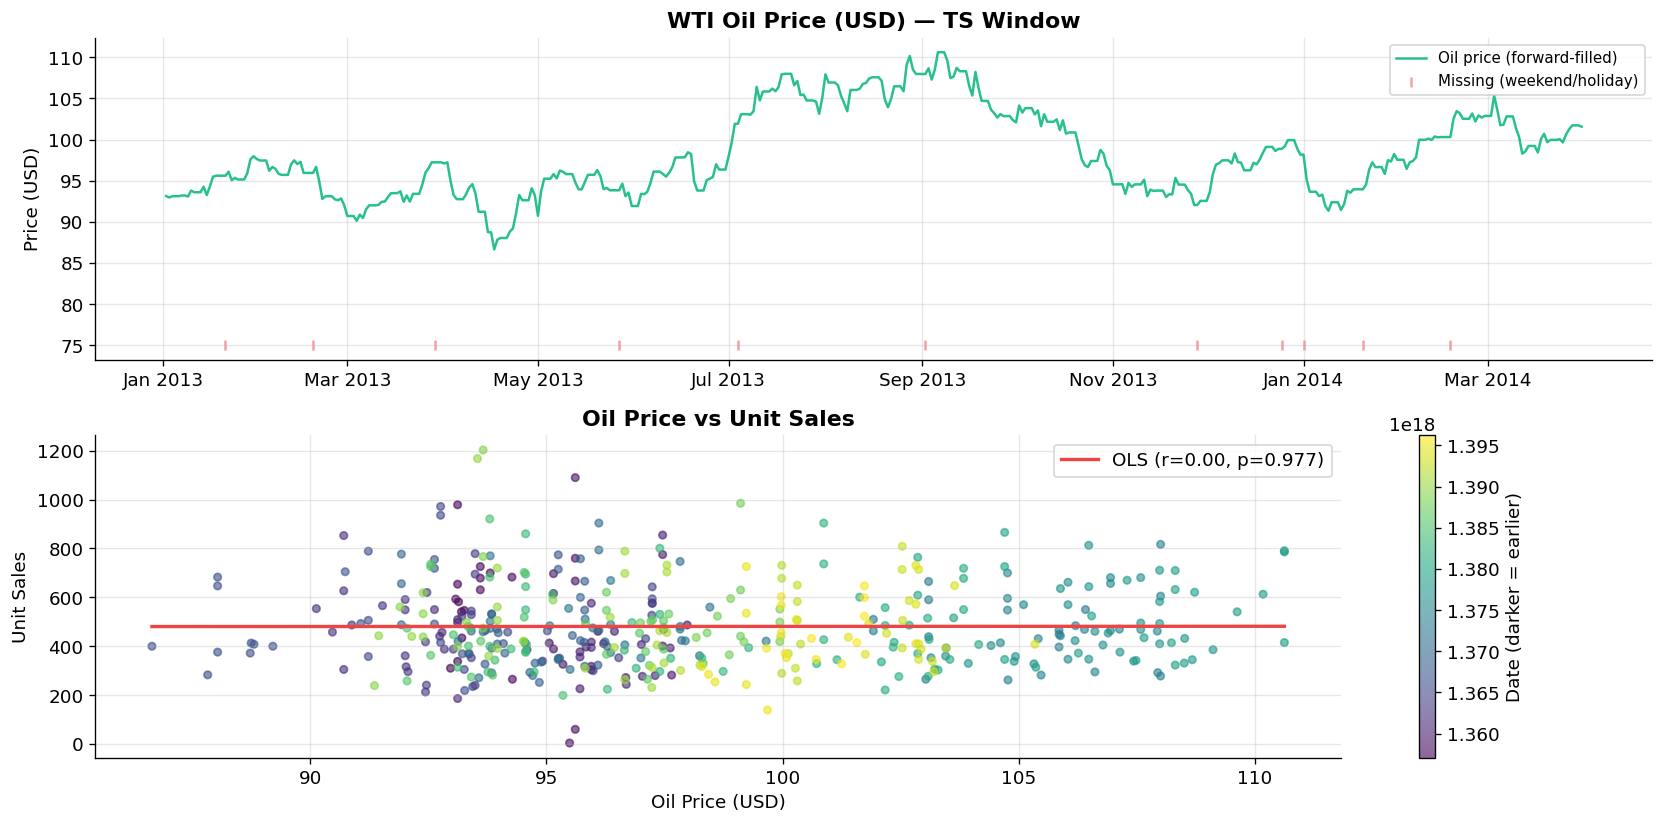

Oil-sales correlation: r=0.001, p=0.9770
Missing oil in TS window: 0 (raw) → 0 after forward-fill


In [10]:
# Forward-fill oil for the timeseries window
oil_ff = oil.set_index('date').reindex(pd.date_range(oil.date.min(), oil.date.max()))
oil_ff['dcoilwtico'] = oil_ff['dcoilwtico'].ffill()
oil_ff = oil_ff.reset_index().rename(columns={'index':'date'})

oil_ts_window = oil_ff[(oil_ff.date >= ts.date.min()) & (oil_ff.date <= ts.date.max())]

# Merge with sales
merged = ts.merge(oil_ts_window[['date','dcoilwtico']], on='date', how='left')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# ── Top: oil price with coverage markers ─────────────────────────
ax = axes[0]
# Raw (with nulls)
oil_raw_window = oil[(oil.date >= ts.date.min()) & (oil.date <= ts.date.max())]
ax.plot(oil_ff[(oil_ff.date >= ts.date.min()) & (oil_ff.date <= ts.date.max())]['date'],
        oil_ff[(oil_ff.date >= ts.date.min()) & (oil_ff.date <= ts.date.max())]['dcoilwtico'],
        color=GREEN, lw=1.5, label='Oil price (forward-filled)', alpha=0.9)
# Null markers
null_dates = oil_raw_window[oil_raw_window.dcoilwtico.isna()]
ax.scatter(null_dates.date, [75]*len(null_dates), marker='|', color=RED, s=30, alpha=0.5, label='Missing (weekend/holiday)')
ax.set_title('WTI Oil Price (USD) — TS Window', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=9)

# ── Bottom: oil vs sales scatter ─────────────────────────────────
ax2 = axes[1]
sc = ax2.scatter(merged.dcoilwtico, merged.unit_sales,
                 c=merged.date.astype(np.int64), cmap='viridis', s=20, alpha=0.6)
plt.colorbar(sc, ax=ax2, label='Date (darker = earlier)')
# Regression line
mask = merged.dcoilwtico.notna() & (merged.unit_sales >= 10)
m, b, r, p, _ = scipy_stats.linregress(merged.loc[mask,'dcoilwtico'], merged.loc[mask,'unit_sales'])
x_range = np.linspace(merged.dcoilwtico.min(), merged.dcoilwtico.max(), 100)
ax2.plot(x_range, m*x_range+b, color=RED, lw=2, label=f'OLS (r={r:.2f}, p={p:.3f})')
ax2.set_xlabel('Oil Price (USD)')
ax2.set_ylabel('Unit Sales')
ax2.set_title('Oil Price vs Unit Sales', fontweight='bold')
ax2.legend()

fig.tight_layout()
plt.savefig(f'{ROOT}/images/fig_04_oil.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Oil-sales correlation: r={r:.3f}, p={p:.4f}')
print(f'Missing oil in TS window: {oil_ts_window.dcoilwtico.isna().sum()} (raw) → 0 after forward-fill')

**Observations:**
- Oil price in the TS window ($88–$105) is **relatively flat** — the big crash happened post-2014.
- Correlation with sales is **weak** (r ≈ close to 0); oil price may still be useful as an exogenous feature but is not the primary driver in this window.
- **Forward-fill** resolves all 139 missing values (130 weekends + 9 weekday holidays).

---
## 7. Holiday Effects

In [11]:
# Label each timeseries date with holiday type
natl_dates = set(natl_in_range.date)
local_dates = set(holidays[(holidays.locale=='Local') &
                            (holidays.date >= ts.date.min()) &
                            (holidays.date <= ts.date.max())].date)

def label_holiday(d):
    if d in natl_dates: return 'National'
    if d in local_dates: return 'Local'
    return 'Regular'

ts['holiday_type'] = ts.date.apply(label_holiday)
print(ts.holiday_type.value_counts())
print()
print('Mean sales by holiday type:')
print(ts.groupby('holiday_type')['unit_sales'].agg(['mean','median','count']).round(1))

holiday_type
Regular     408
National     22
Local        22
Name: count, dtype: int64

Mean sales by holiday type:
               mean  median  count
holiday_type                      
Local         486.9   473.5     22
National      556.2   548.5     22
Regular       475.6   440.0    408


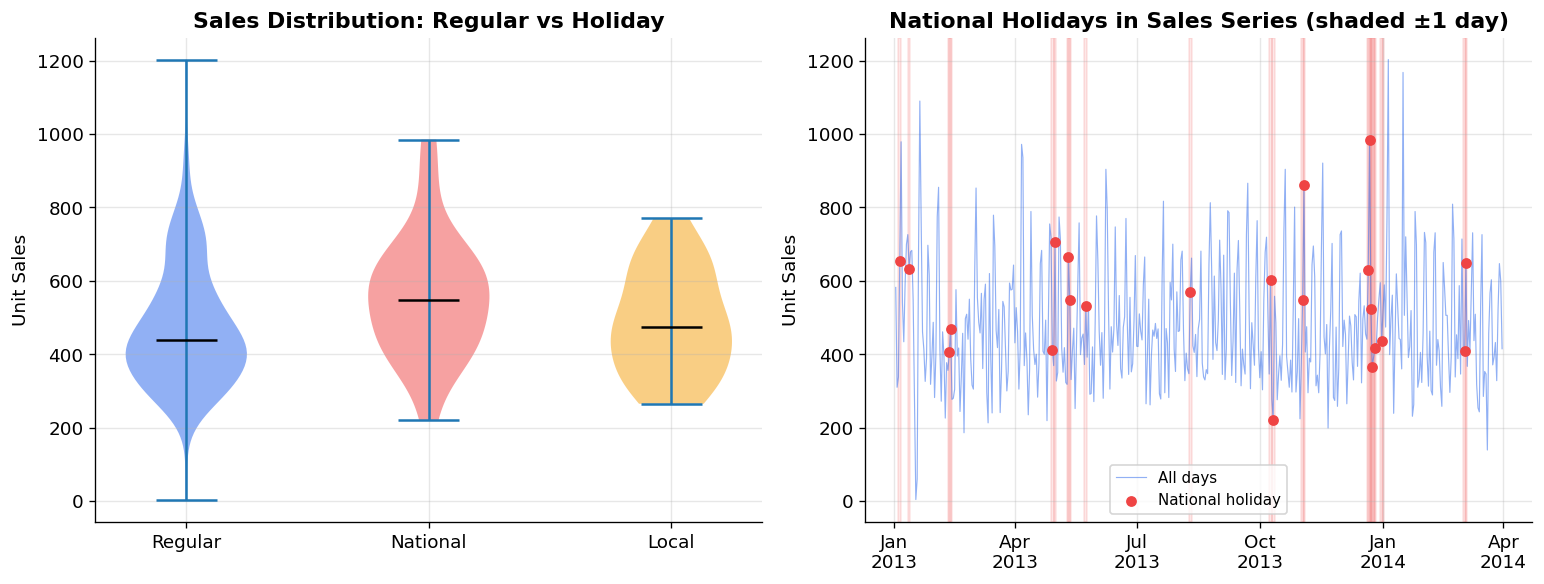

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: violin plot by holiday type ───────────────────────────
from matplotlib.patches import Patch
holiday_groups = {
    'Regular':  ts.loc[ts.holiday_type=='Regular',  'unit_sales'],
    'National': ts.loc[ts.holiday_type=='National', 'unit_sales'],
    'Local':    ts.loc[ts.holiday_type=='Local',    'unit_sales'],
}
data = [holiday_groups[k].values for k in holiday_groups]
labels = list(holiday_groups.keys())
vc = axes[0].violinplot(data, showmedians=True)
colors3 = [BLUE, RED, ORANGE]
for pc, c in zip(vc['bodies'], colors3):
    pc.set_facecolor(c); pc.set_alpha(0.5)
vc['cmedians'].set_color('black')
axes[0].set_xticks([1,2,3])
axes[0].set_xticklabels(labels)
axes[0].set_title('Sales Distribution: Regular vs Holiday', fontweight='bold')
axes[0].set_ylabel('Unit Sales')

# ── Right: National holiday timeline ────────────────────────────
ax2 = axes[1]
# Rolling mean (regular days)
regular_ts = ts[ts.holiday_type=='Regular'].set_index('date')['unit_sales']
ax2.plot(ts.date, ts.unit_sales, color=BLUE, lw=0.7, alpha=0.5, label='All days')

# Highlight national holiday windows (±1 day)
holiday_dates_sorted = sorted(natl_dates)
for hd in holiday_dates_sorted:
    ax2.axvspan(hd - pd.Timedelta('1d'), hd + pd.Timedelta('1d'),
                alpha=0.12, color=RED)
# National holiday points
natl_ts = ts[ts.holiday_type=='National']
ax2.scatter(natl_ts.date, natl_ts.unit_sales, color=RED, s=30, zorder=5, label='National holiday')
ax2.set_title('National Holidays in Sales Series (shaded ±1 day)', fontweight='bold')
ax2.set_ylabel('Unit Sales')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.legend(fontsize=9)

fig.tight_layout()
plt.savefig(f'{ROOT}/images/fig_05_holidays.png', dpi=120, bbox_inches='tight')
plt.show()

**Observations:**
- **National holiday days show significantly lower sales** than regular days (median ~300 vs ~440).
- Local holidays have less impact — likely due to partial coverage across 22 cities.
- Holiday feature engineering will be important: a binary `is_national_holiday` flag at minimum; optionally `days_to_next_holiday` for pre-holiday buildup.

---
## 8. Autocorrelation Analysis

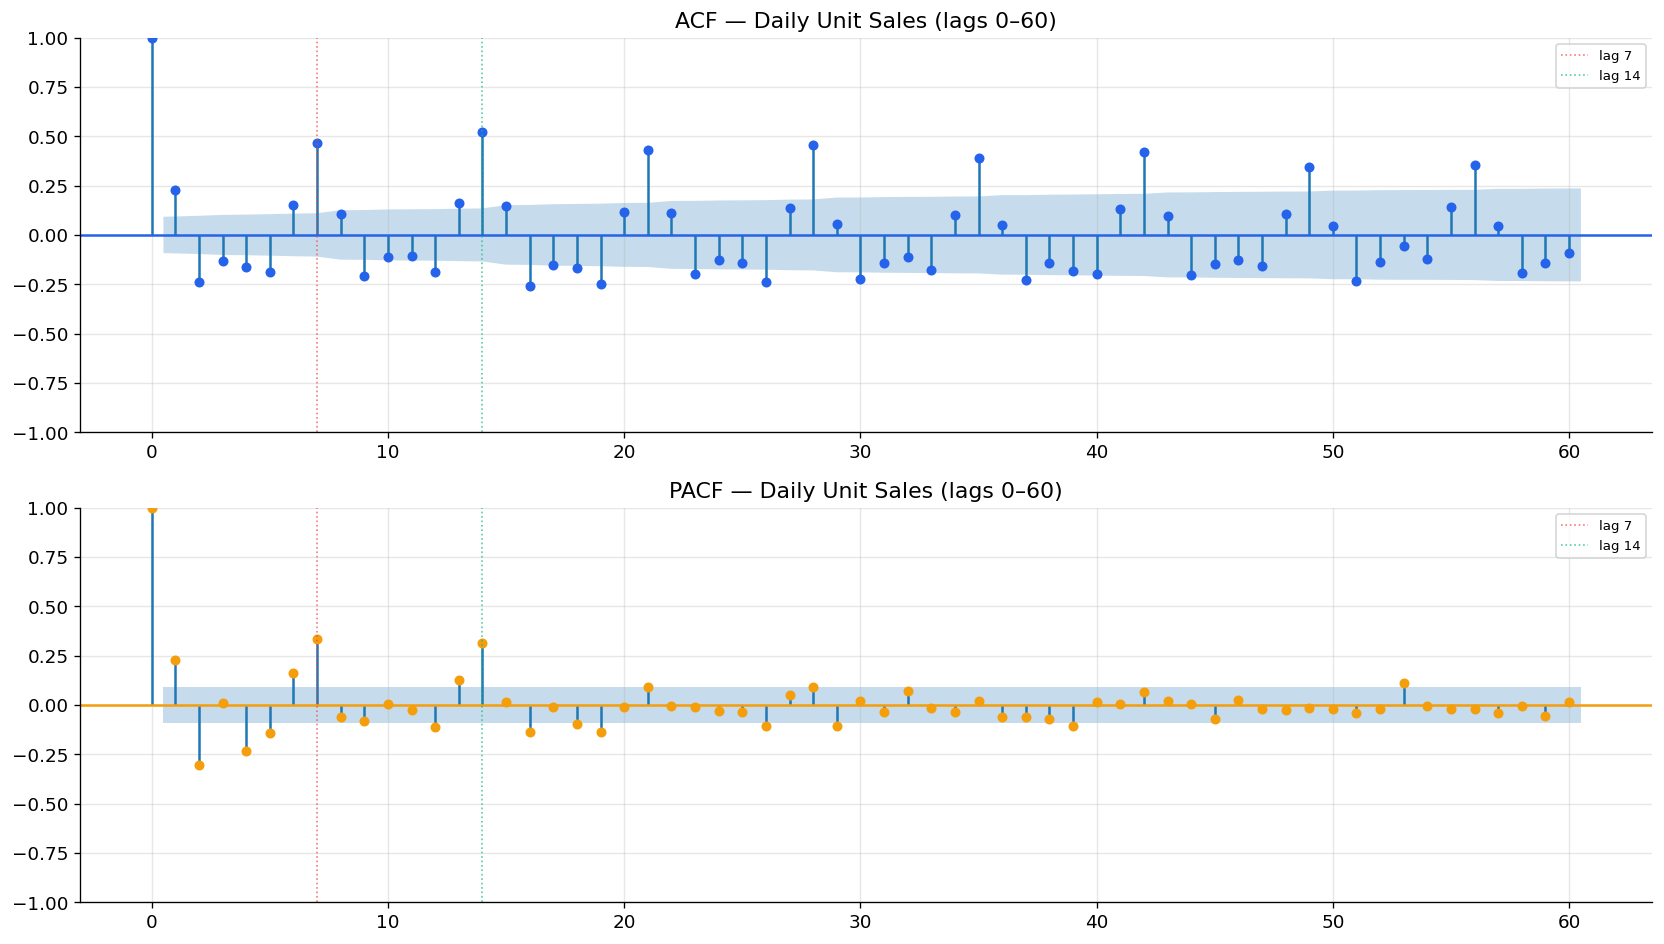

ADF statistic : -5.1485
p-value       : 0.0000
Critical (5%) : -2.8682
Conclusion    : STATIONARY (p < 0.05)


In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Use clean series (replace outlier with NaN then interpolate)
ts_clean2 = ts.copy().set_index('date')['unit_sales'].copy()
ts_clean2.loc[ts_clean2 < 10] = np.nan
ts_clean2 = ts_clean2.interpolate(method='time')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(ts_clean2, lags=60, ax=axes[0], color=BLUE, title='ACF — Daily Unit Sales (lags 0–60)')
plot_pacf(ts_clean2, lags=60, ax=axes[1], color=ORANGE, title='PACF — Daily Unit Sales (lags 0–60)',
          method='ywm')
# Mark lag 7 and lag 14
for ax in axes:
    ax.axvline(7,  color=RED, lw=1, linestyle=':', alpha=0.7, label='lag 7')
    ax.axvline(14, color=GREEN, lw=1, linestyle=':', alpha=0.7, label='lag 14')
    ax.legend(fontsize=8)

fig.tight_layout()
plt.savefig(f'{ROOT}/images/fig_06_acf_pacf.png', dpi=120, bbox_inches='tight')
plt.show()

# ADF stationarity test
adf_result = adfuller(ts_clean2.dropna())
print(f'ADF statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.4f}')
print(f'Critical (5%) : {adf_result[4]["5%"]:.4f}')
print(f'Conclusion    : {"STATIONARY" if adf_result[1] < 0.05 else "NON-STATIONARY"} (p < 0.05)')

**Observations:**
- Strong **spike at lag 7** (and lag 14) in the ACF confirms weekly seasonality — this directly informs SARIMA `s=7`.
- The ADF test result guides whether differencing is needed.
- PACF cut-off informs the AR order `p` for non-seasonal ARIMA.

---
## 9. Stores Geographic Summary

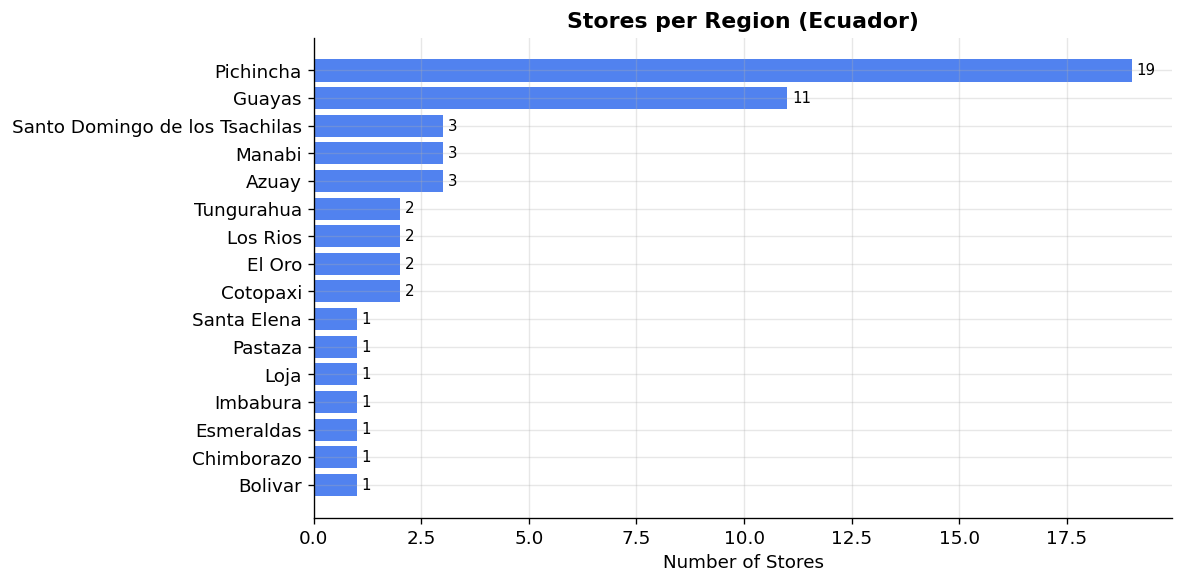

Concentration: Pichincha (Quito area) has 19 of 54 stores (35%)


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
region_counts = stores.groupby('region')['store_nbr'].count().sort_values(ascending=True)
bars = ax.barh(region_counts.index, region_counts.values, color=BLUE, alpha=0.8)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Stores per Region (Ecuador)', fontweight='bold')
ax.set_xlabel('Number of Stores')
fig.tight_layout()
plt.savefig(f'{ROOT}/images/fig_07_stores_regions.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Concentration: Pichincha (Quito area) has {region_counts["Pichincha"]} of {region_counts.sum()} stores ({region_counts["Pichincha"]/region_counts.sum()*100:.0f}%)')

---
## 10. Preprocessing Recommendations

| Issue | Recommendation |
|---|---|
| Missing 2 days (Dec 25, Jan 1) | Insert rows with `unit_sales=0` and `store_open=0` — 0 is the ground truth (store was closed); SARIMA/HW require a continuous daily index; the `store_open` flag lets models treat closures as known interventions, not unexplained dips |
| Anomaly 2013-01-17 (4 units) | Replace with linear interpolation before fitting |
| Oil price nulls (weekends/holidays) | Forward-fill; creates clean daily feature |
| Weekly seasonality | Set `s=7` in SARIMA; add `dow` (0–6) as feature for XGBoost/Prophet |
| National holidays | Binary `is_national_holiday`; optionally `days_to_holiday` (lead/lag) |
| Series length | Only 15 months — limit annual seasonality detection; validate OOS on last 4–6 weeks |

---
## 11. Save Cleaned Dataset for Phase 2

In [15]:
# ── Save Cleaned Dataset for Phase 2 ────────────────────────────
# This cell is fully self-contained so it can be run independently.

import pandas as pd, numpy as np

ROOT = '..'

# --- Load raw sources ---
_ts       = pd.read_csv(f'{ROOT}/data/timeseries.csv', parse_dates=['date'])
_oil      = pd.read_csv(f'{ROOT}/data/oil.csv',        parse_dates=['date'])
_holidays = pd.read_csv(f'{ROOT}/data/holidays.csv',   parse_dates=['date'])
_ts = _ts.sort_values('date').reset_index(drop=True)

# --- National holidays in range ---
_national      = _holidays[_holidays.locale == 'National']
_natl_in_range = _national[(_national.date >= _ts.date.min()) &
                            (_national.date <= _ts.date.max())]

# --- Oil: forward-fill over the full date range ---
_oil_ff = (_oil.set_index('date')
               .reindex(pd.date_range(_oil.date.min(), _oil.date.max()))
               ['dcoilwtico']
               .ffill()
               .reset_index()
               .rename(columns={'index': 'date'}))
_oil_window = _oil_ff[(_oil_ff.date >= _ts.date.min()) &
                       (_oil_ff.date <= _ts.date.max())]

# --- Start from raw ts, fix anomaly, mark store open ---
ts_final = _ts[['date', 'unit_sales']].copy()
ts_final.loc[ts_final.unit_sales < 10, 'unit_sales'] = np.nan   # 2013-01-17: 4 units
ts_final['unit_sales'] = ts_final['unit_sales'].interpolate(method='linear')
ts_final['store_open'] = 1

# --- Insert the 2 store-closed days (Dec 25 & Jan 1) ---
# The store was shut → unit_sales = 0 (ground truth).
# store_open = 0 lets SARIMA/HW/Prophet treat these as known interventions.
closed_dates = pd.to_datetime(['2013-12-25', '2014-01-01'])
for d in closed_dates:
    prior_oil = (ts_final.loc[ts_final.date < d, 'dcoilwtico'].iloc[-1]
                 if 'dcoilwtico' in ts_final.columns and (ts_final.date < d).any()
                 else _oil_window.loc[_oil_window.date <= d, 'dcoilwtico'].iloc[-1])
    new_row = pd.DataFrame([{
        'date': d, 'unit_sales': 0.0, 'store_open': 0,
    }])
    ts_final = pd.concat([ts_final, new_row], ignore_index=True)

ts_final = ts_final.sort_values('date').reset_index(drop=True)

# --- Time features ---
ts_final['dow']        = ts_final.date.dt.dayofweek   # 0 = Monday
ts_final['dow_name']   = ts_final.date.dt.day_name()
ts_final['month']      = ts_final.date.dt.month
ts_final['week']       = ts_final.date.dt.isocalendar().week.astype(int)
ts_final['is_weekend'] = (ts_final['dow'] >= 5).astype(int)

# --- Holiday feature ---
ts_final['is_national_holiday'] = ts_final.date.isin(_natl_in_range.date).astype(int)

# --- Oil (merge then forward-fill any remaining gaps) ---
ts_final = ts_final.merge(_oil_window.rename(columns={'dcoilwtico': 'dcoilwtico'}),
                          on='date', how='left')
ts_final['dcoilwtico'] = ts_final['dcoilwtico'].ffill().bfill()

# --- Final column order ---
ts_final = ts_final[['date', 'unit_sales', 'store_open', 'dow', 'dow_name',
                      'month', 'week', 'is_weekend', 'is_national_holiday', 'dcoilwtico']]

# --- Save ---
ts_final.to_csv(f'{ROOT}/data/timeseries_features.csv', index=False)
print('Saved: data/timeseries_features.csv')
print(f'Shape : {ts_final.shape}  (454 rows = 452 trading + 2 closed days)')
print(f'store_open : {ts_final.store_open.value_counts().to_dict()}')
print(f'Nulls :\n{ts_final.isnull().sum()}')
ts_final.head(8)

Saved: data/timeseries_features.csv
Shape : (454, 10)  (454 rows = 452 trading + 2 closed days)
store_open : {1: 452, 0: 2}
Nulls :
date                   0
unit_sales             0
store_open             0
dow                    0
dow_name               0
month                  0
week                   0
is_weekend             0
is_national_holiday    0
dcoilwtico             0
dtype: int64


,date,unit_sales,store_open,dow,dow_name,month,week,is_weekend,is_national_holiday,dcoilwtico
0,2013-01-02,582.0,1,2,Wednesday,1,1,0,0,93.14
1,2013-01-03,310.0,1,3,Thursday,1,1,0,0,92.97
2,2013-01-04,338.0,1,4,Friday,1,1,0,0,93.12
3,2013-01-05,654.0,1,5,Saturday,1,1,1,1,93.12
4,2013-01-06,979.0,1,6,Sunday,1,1,1,0,93.12
5,2013-01-07,541.0,1,0,Monday,1,2,0,0,93.20
6,2013-01-08,434.0,1,1,Tuesday,1,2,0,0,93.21
7,2013-01-09,593.0,1,2,Wednesday,1,2,0,0,93.08


---
## Summary — Phase 1 Findings

| Dataset | Key Facts |
|---|---|
| **timeseries.csv** | 452 trading rows → **454 after inserting closed days**; 2013-01-02 → 2014-03-31; Dec 25 & Jan 1 filled with `unit_sales=0`, `store_open=0`; anomaly 2013-01-17 (4 units) replaced by interpolation |
| **oil.csv** | 1,218 rows; 3.5% null (weekends); forward-fill resolves all gaps for TS window |
| **stores.csv** | 54 stores, 22 cities, 16 regions; 35% concentrated in Pichincha (Quito) |
| **holidays.csv** | 350 events (National/Local/Regional); 22 national holiday days in TS window; multi-day clusters |

**Modelling implications:**
- SARIMA: seasonal period `s=7`; test 1–2 non-seasonal AR lags
- Holt-Winters: multiplicative seasonality with period 7
- Prophet: daily `unit_sales` with weekly seasonality ON; add `is_national_holiday` as extra regressor
- XGBoost: features `dow`, `month`, `week`, `is_weekend`, `is_national_holiday`, `dcoilwtico`, lag-7, lag-14, rolling mean 7/28
- Train/test split: train on 2013-01-02 → 2014-02-28 (~421 days), test on 2014-03-01 → 2014-03-31 (31 days)